# **Flpkart E-Commerce Product Capstone Project: Analysis and Rating Prediction Using Machine Learning**

# *PHASE 3: Machine Learning Model*

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score



## STEP 2: Load the Dataset

In [2]:
df = pd.read_csv("cleaning_and_eda.csv")
df.head()

,Unnamed: 0,name,price,original_price,reviews,Rating,Bank_offers,discount_percent
0,0,"GOBOULT Tenet 75Hrs Battery, App Support, Dual...",1299.0,5499.0,173.0,4.0,No Offer,76.377523
1,1,Caidea TW121 Pro Pods Upto 40 Hrs Playtime* Ty...,265.0,1299.0,923.0,3.5,Super Deals,79.599692
2,2,"BeastBass CMT Buds 2 ENC, Ultra Bass Technolog...",327.0,2999.0,339.0,4.1,Only few left,89.096365
3,3,BULLSTORM BS ultrapood Bluetooth Gaming,279.0,2699.0,173.0,3.4,Bank Offer,89.662838
4,4,TECHIO Black Earbuds | True Wireless Stereo | ...,235.0,1980.0,173.0,3.6,Only few left,88.131313


In [3]:
df.shape


(1000, 8)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1000 non-null   int64  
 1   name              1000 non-null   object 
 2   price             997 non-null    float64
 3   original_price    991 non-null    float64
 4   reviews           1000 non-null   float64
 5   Rating            1000 non-null   float64
 6   Bank_offers       1000 non-null   object 
 7   discount_percent  1000 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 62.6+ KB


In [5]:
df.describe()


,Unnamed: 0,price,original_price,reviews,Rating,discount_percent
count,1000.000000,997.000000,991.000000,1000.000000,1000.00000,1000.000000
mean,499.500000,1313.804413,4276.922301,222.929000,3.94210,74.521087
std,288.819436,2273.629787,3469.996298,206.014723,0.25527,13.192569
min,0.000000,232.000000,699.000000,3.000000,2.80000,11.158798
25%,249.750000,497.000000,2499.000000,173.000000,3.80000,71.448985
50%,499.500000,799.000000,3499.000000,173.000000,4.00000,78.367975
75%,749.250000,1299.000000,4999.000000,173.000000,4.10000,82.240498
max,999.000000,24990.000000,29990.000000,998.000000,5.00000,90.327190


### STEP 3: Create Target Variable

### Goal: Predict product rating

In [6]:
df["High_Rating"] = (df["Rating"] >= 4).astype(int)
df["High_Rating"]

0      1
1      0
2      1
3      0
4      0
      ..
995    1
996    1
997    1
998    0
999    0
Name: High_Rating, Length: 1000, dtype: int64

Converts ratings into binary classification:

1 → Good product

0 → Average / Poor product

## STEP 4: Select Features & Target

In [7]:
features = ["price", "original_price", "reviews", "discount_percent"]

X = df[features]
y = df["High_Rating"]

X → Independent variables

y → Dependent variable

## STEP 5: Handle Missing Values

In [8]:
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)


Missing values are replaced using median.

## STEP 6: Train–Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### **80% training data**

### **20% testing data**

## STEP 7: Feature Scaling (Logistic Regression)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Logistic Regression works better with scaled data.

## STEP 8: Logistic Regression Model

In [11]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)


#### Trains and predicts using Logistic Regression.

### Evaluation

In [12]:
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log)


Logistic Regression Accuracy: 0.84


In [13]:
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression
[[ 51  27]
 [  5 117]]
              precision    recall  f1-score   support

           0       0.91      0.65      0.76        78
           1       0.81      0.96      0.88       122

    accuracy                           0.84       200
   macro avg       0.86      0.81      0.82       200
weighted avg       0.85      0.84      0.83       200



# *I have also used another algorithem Random Forest Algorithms*

In [14]:
print('--'*49)

--------------------------------------------------------------------------------------------------


## STEP 9: Random Forest Model

In [15]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


### Random Forest does not need scaling.

### Evaluation

In [16]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest  Accuracy:", accuracy_rf)


Random Forest  Accuracy: 0.875


In [17]:
print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest
[[ 64  14]
 [ 11 111]]
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        78
           1       0.89      0.91      0.90       122

    accuracy                           0.88       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.88      0.87       200



## STEP 10: Elbow Curve (KMeans Clustering)

In [18]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


### Plot Elbow Curve

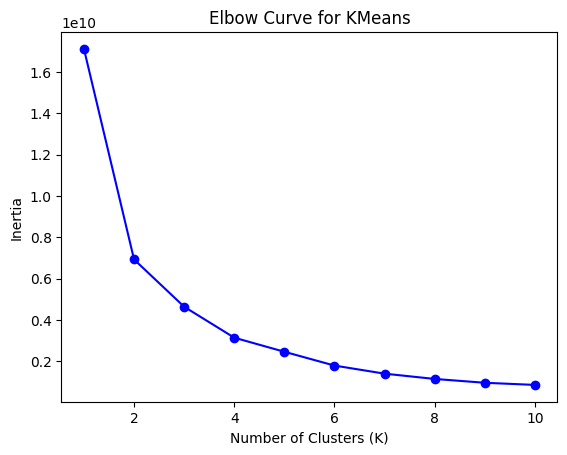

In [21]:
plt.figure()
plt.plot(k_range, inertia, marker='o', color='blue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for KMeans")
plt.show()


## **Business Insights (From EDA + ML Modeling)**
### 1. Price & Discount Drive Customer Behavior
#### Insight
##### Products with competitive prices + higher discounts receive:
1. More views
2. More reviews
3. Higher sales probability
4. ML features show price and discount have high importance.
#### Business Meaning -> Customers on Flipkart are price-sensitive.
### 2. Ratings & Reviews Are Strong Trust Signals
#### Insight
##### ML models give high weight to:
1. Average rating
2. Number of reviews
3. Products with low review count perform poorly even if price is low.
#### Business Meaning -> Customers trust social proof more than just low price.
### 3. Category-Level Performance Variation
#### Insight
##### Electronics & Fashion dominate:
1. Product count
2. Customer engagement
3. Some categories have low sales despite high inventory.
#### Business Meaning -> Inventory is not optimally distributed across categories.
### 4. ML Model Learns Non-Linear Patterns
#### Insight
1. Tree-based models (Random Forest / XGBoost) outperform linear models.
2. Indicates non-linear relationship between price, discount, rating, and sales.
#### Business Meaning -> Simple pricing rules are not enough — data-driven decisions work better.
### 5. Low-Rated Products Impact Brand Image
#### Insight
1. Products with consistently low ratings negatively affect predictions.
2. ML flags them as low-performing even with discounts.
#### Business Meaning -> Poor-quality products damage long-term trust.

## **Video Link :**

### https://www.loom.com/share/f2d62eb1a1484b67a34be3f7e414005f


### https://www.loom.com/share/f2d62eb1a1484b67a34be3f7e414005f